# Capítulo 4 — Hartree-Fock e o Diagrama de Orbitais do Ponto Quântico

**Simulando Qubits com PySCF** · Cristiano Alves

No Capítulo 3 construímos a geometria; agora vamos calcular sua **estrutura eletrônica**. Submeteremos os nanocristais a cálculos Hartree-Fock, extrairemos seu **diagrama de orbitais** e mediremos como o *gap* responde ao tamanho — pondo à prova, átomo a átomo, o confinamento quântico.

Ao final localizaremos o **orbital do doador**: o estado que hospeda o elétron do nosso *qubit*.

> ⏱️ **Atenção ao tempo.** Este *notebook* executa cálculos de verdade em sistemas de centenas de funções de base. A varredura da Seção 4.4 é a parte mais pesada. Execute as células **na ordem** (`Shift+Enter`).

In [1]:
# !pip install pyscf matplotlib

## Reaproveitando o Capítulo 3

As funções de geometria construídas no capítulo anterior serão usadas o tempo todo. A célula abaixo as reúne — é a mesma lógica, sem novidades.

> 💡 Note a função `geometria()`: ela devolve a lista de átomos **sem o cabeçalho** do formato `.xyz` (contagem + comentário), que é exatamente o que o `gto.M` espera receber.

In [2]:
import numpy as np

A_SI, D_SIH, CORTE = 5.431, 1.48, 2.6

def rede_diamante(n_celulas):
    base = np.array([[0, 0, 0], [.25, .25, .25], [0, .5, .5], [.25, .75, .75],
                     [.5, 0, .5], [.75, .25, .75], [.5, .5, 0], [.75, .75, .25]])
    celulas = np.array([[i, j, k] for i in range(n_celulas)
                        for j in range(n_celulas) for k in range(n_celulas)])
    return (celulas[:, None, :] + base[None, :, :]).reshape(-1, 3) * A_SI

def construir_nanocristal(diametro_nm, n_celulas=8, min_viz=2):
    raio = diametro_nm * 10 / 2
    rede = rede_diamante(n_celulas)
    rede = rede - rede.mean(axis=0)
    dentro = np.linalg.norm(rede, axis=1) <= raio
    while True:
        idx = np.where(dentro)[0]
        pos = rede[idx]
        nviz = [np.sum((np.linalg.norm(pos - p, axis=1) > 0.1) &
                       (np.linalg.norm(pos - p, axis=1) < CORTE)) for p in pos]
        ruins = idx[np.array(nviz) < min_viz]
        if len(ruins) == 0:
            break
        dentro[ruins] = False
    si = rede[dentro]
    hidrogenios = []
    for p in si:
        d = np.linalg.norm(rede - p, axis=1)
        for j in np.where((d > 0.1) & (d < CORTE))[0]:
            if not dentro[j]:
                hidrogenios.append(p + D_SIH * (rede[j] - p) / d[j])
    return si, np.array(hidrogenios)

def inserir_doador(si):
    """Indice do Si mais proximo do centro, a ser trocado por P."""
    return int(np.argmin(np.linalg.norm(si, axis=1)))

def geometria(si, h, idx_p=None):
    """String de atomos pronta para o gto.M (sem cabecalho .xyz)."""
    L = []
    for i, p in enumerate(si):
        L.append("%-2s %10.6f %10.6f %10.6f" % ("P" if i == idx_p else "Si", *p))
    for p in h:
        L.append("%-2s %10.6f %10.6f %10.6f" % ("H", *p))
    return "\n".join(L)

si, h = construir_nanocristal(0.8)
print("Teste: Si%dH%d (%d atomos)" % (len(si), len(h), len(si) + len(h)))

Teste: Si10H16 (26 atomos)


## 4.1 O formalismo SCF para muitos elétrons

O Hartree-Fock busca os orbitais $\{\psi_i\}$ que minimizam a energia, sob a hipótese de que a função de onda total é um único determinante de Slater. Expandindo cada orbital na base $\psi_i = \sum_\mu C_{\mu i}\phi_\mu$, essa condição vira as **equações de Roothaan-Hall**:

$$\mathbf{F}\,\mathbf{C} = \mathbf{S}\,\mathbf{C}\,\boldsymbol{\varepsilon}.$$

Aqui $\mathbf{C}$ são os coeficientes orbitais, $\boldsymbol{\varepsilon}$ as energias, $\mathbf{S}$ a matriz de sobreposição e $\mathbf{F}$ a **matriz de Fock**.

O ponto crucial: **$\mathbf{F}$ depende dos próprios orbitais** que queremos encontrar. É o ovo e a galinha, e a saída é iterar até a autoconsistência:

1. Parte-se de uma densidade inicial (o *guess*).
2. Monta-se $\mathbf{F}$ a partir dessa densidade.
3. Resolve-se o problema de autovalores, obtendo novos $\mathbf{C}$ e $\boldsymbol{\varepsilon}$.
4. Constrói-se a nova densidade e volta-se ao passo 2.

> 💡 **Por que o custo cresce tão rápido.** Montar a matriz de Fock exige as *integrais de repulsão de dois elétrons*, cujo número escala formalmente com $N^4$ ($N$ = funções de base). Dobrar o sistema multiplica o custo por até dezesseis. Veremos isso com os próprios olhos na Seção 4.4.

Vamos **assistir** ao ciclo SCF acontecer. Com `verbose=4` o PySCF imprime cada iteração:

In [3]:
from pyscf import gto, scf

si, h = construir_nanocristal(0.8)
mol = gto.M(atom=geometria(si, h), basis="sto-3g", verbose=4)
print("Sistema: Si%dH%d | %d eletrons | %d funcoes de base\n"
      % (len(si), len(h), mol.nelectron, mol.nao))

mf = scf.RHF(mol)
energia = mf.kernel()

System: uname_result(system='Linux', node='cristianoalves-nitro-pro-n7', release='6.8.0-134-generic', version='#134-Ubuntu SMP PREEMPT_DYNAMIC Fri Jun 26 18:43:11 UTC 2026', machine='x86_64')  Threads 16
Python 3.11.7 (main, Dec 15 2023, 18:12:31) [GCC 11.2.0]
numpy 2.4.4  scipy 1.16.2  h5py 3.14.0
Date: Sat Jul 25 14:58:28 2026
PySCF version 2.14.0
PySCF path  /home/cristianoalves/anaconda3/lib/python3.11/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 26
[INPUT] num. electrons = 156
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 Si    -3.394375000000  -0.678875000000  -0.678875000000 AA   -6.414439114071  -1.282887822814  -1.282887822814 Bohr   0.0
[INPUT]  2 Si    -0.678875000000  -3.394375000000  -0.678875000000 AA   -1.2

number of shells = 66


number of NR pGTOs = 318


number of NR cGTOs = 106


basis = sto-3g


...

  HOMO = -0.266093256087286  LUMO = 0.352136589533571  gap/eV = 16.82289


cycle= 7 E= -2865.5951903419  delta_E= -5.75e-10  |g|= 3.52e-06  |ddm|= 9.54e-05


  HOMO = -0.266093816220521  LUMO = 0.352135835266101  gap/eV = 16.82289


Extra cycle  E= -2865.59519034188  delta_E= 2.18e-11  |g|= 1.06e-06  |ddm|= 9.05e-06


converged SCF energy = -2865.59519034188


Repare na coluna `|ddm|`: é a variação da matriz de densidade entre ciclos. Ela **despenca** — obra do algoritmo **DIIS**, que extrapola as matrizes de Fock anteriores para dar saltos maiores rumo à solução.

## 4.2 Controle de convergência

Para a H₂ o SCF convergiu sem esforço. Para um nanocristal com centenas de elétrons e níveis próximos, a convergência pode ser lenta — ou falhar. O PySCF traz ferramentas maduras:

In [4]:
mf = scf.RHF(mol)
mf.init_guess = "minao"   # padrao; alternativas: '1e', 'atom', 'huckel'
mf.max_cycle = 200        # mais iteracoes (padrao: 50)
mf.conv_tol = 1e-8        # criterio de convergencia da energia (Ha)
mf.level_shift = 0.0      # afasta ocupados de virtuais; use 0.2-0.5 se oscilar
mf.diis_space = 12        # mais memoria de Fock para o DIIS
mf.verbose = 0            # silencia a saida

energia = mf.kernel()
print("Convergiu? %s   Energia = %.6f Ha   ciclos usados: <= %d"
      % (mf.converged, energia, mf.max_cycle))

Convergiu? True   Energia = -2865.595190 Ha   ciclos usados: <= 200


> ⚠️ **Nunca confie num cálculo que imprimiu `SCF not converged`.** Antes de ler qualquer energia orbital ou *gap*, verifique `mf.converged` (deve ser `True`). Um diagrama de orbitais extraído de um SCF não convergido é literalmente ruído.
>
> O `level_shift` é o remédio mais eficaz contra oscilações: desloca os orbitais virtuais para cima, evitando que ocupados e virtuais "troquem de lugar" entre ciclos.

## 4.3 O diagrama de orbitais e o *gap* de confinamento

Convergido o SCF, o resultado mais rico é o **diagrama de orbitais**: a lista ordenada das energias $\varepsilon_i$. O **HOMO** é o mais alto ocupado, o **LUMO** o mais baixo vazio, e

$$E_g = \varepsilon_{\text{LUMO}} - \varepsilon_{\text{HOMO}}.$$

Para um ponto quântico esse *gap* tem significado físico direto: é a **energia de confinamento**.

In [5]:
HARTREE_EV = 27.2114

def gap_homo_lumo(mf):
    """Gap HOMO-LUMO (eV) de um calculo de camada fechada convergido."""
    assert mf.converged, "SCF nao convergiu!"
    n_ocupados = int(mf.mo_occ.sum() // 2)
    homo = mf.mo_energy[n_ocupados - 1]
    lumo = mf.mo_energy[n_ocupados]
    return (lumo - homo) * HARTREE_EV, homo, lumo, n_ocupados

gap, homo, lumo, no = gap_homo_lumo(mf)
print("Orbitais ocupados : %d de %d" % (no, len(mf.mo_energy)))
print("HOMO              : %+.4f Ha" % homo)
print("LUMO              : %+.4f Ha" % lumo)
print("Gap HOMO-LUMO     : %.2f eV" % gap)

Orbitais ocupados : 78 de 106
HOMO              : -0.2661 Ha
LUMO              : +0.3521 Ha
Gap HOMO-LUMO     : 16.82 eV


Vamos **ver** o diagrama: cada traço é um nível de energia, e a faixa vazia no meio é o *gap*.

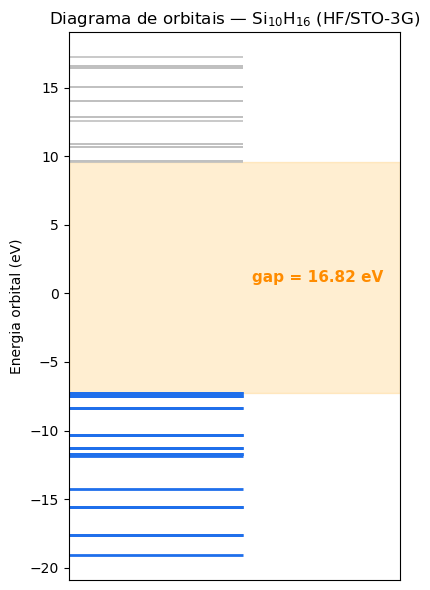

In [6]:
import matplotlib.pyplot as plt

e = mf.mo_energy * HARTREE_EV
janela = 25                                   # niveis de cada lado do gap
sel = slice(max(0, no - janela), no + janela)

fig, ax = plt.subplots(figsize=(4.2, 6))
for i, ei in enumerate(e[sel], start=max(0, no - janela)):
    cor, lw = ("#1f6feb", 2.0) if i < no else ("#c0c0c0", 1.2)
    ax.hlines(ei, 0, 1, color=cor, lw=lw)

ax.axhspan(homo * HARTREE_EV, lumo * HARTREE_EV, color="orange", alpha=0.18)
ax.annotate("gap = %.2f eV" % gap, xy=(1.05, (homo + lumo) / 2 * HARTREE_EV),
            va="center", fontsize=11, color="darkorange", weight="bold")
ax.set_xlim(0, 1.9); ax.set_xticks([])
ax.set_ylabel("Energia orbital (eV)")
ax.set_title("Diagrama de orbitais — Si$_{10}$H$_{16}$ (HF/STO-3G)")
plt.tight_layout(); plt.show()

Os níveis azuis estão ocupados; os cinzas, vazios. A faixa laranja é o *gap*.

## 4.4 Mãos à Obra: a varredura do *gap* versus tamanho

Agora o experimento numérico que dá título ao capítulo: calcular o *gap* para uma série de nanocristais e observar a tendência.

> ⏱️ **Esta é a célula mais lenta do notebook.** O custo cresce como $N^4$: o ponto de 1,2 nm sozinho pode levar vários minutos. Se quiser um teste rápido, remova o `1.2` da lista.

In [7]:
import time

diametros, gaps, tempos, tamanhos = [], [], [], []

for d in [0.8, 0.9, 1.0, 1.2]:
    t0 = time.time()
    si, h = construir_nanocristal(d)
    mol = gto.M(atom=geometria(si, h), basis="sto-3g", verbose=0)
    mf_d = scf.RHF(mol)
    mf_d.kernel()
    g, _, _, _ = gap_homo_lumo(mf_d)
    dt = time.time() - t0

    diametros.append(d); gaps.append(g); tempos.append(dt); tamanhos.append(mol.nao)
    print("D=%.1f nm  Si%dH%d  nao=%3d  gap=%5.2f eV  (%.0f s)"
          % (d, len(si), len(h), mol.nao, g, dt), flush=True)

D=0.8 nm  Si10H16  nao=106  gap=16.82 eV  (3 s)


D=0.9 nm  Si19H28  nao=199  gap=14.76 eV  (8 s)


D=1.0 nm  Si22H28  nao=226  gap=14.61 eV  (10 s)


D=1.2 nm  Si36H40  nao=364  gap=13.65 eV  (134 s)


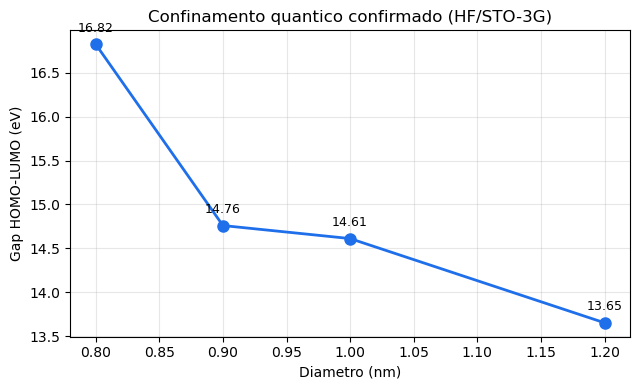

In [8]:
plt.figure(figsize=(6.5, 4))
plt.plot(diametros, gaps, "o-", lw=2, ms=8, color="#1f6feb")
for x, y in zip(diametros, gaps):
    plt.annotate("%.2f" % y, (x, y), textcoords="offset points",
                 xytext=(0, 9), ha="center", fontsize=9)
plt.xlabel("Diametro (nm)"); plt.ylabel("Gap HOMO-LUMO (eV)")
plt.title("Confinamento quantico confirmado (HF/STO-3G)")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("gap_vs_tamanho.png", dpi=150)   # mesma figura do livro
plt.show()

**A tendência é inequívoca e confirma o confinamento quântico:** quanto menor o nanocristal, maior o *gap* — exatamente a assinatura $E_g \propto 1/R^2$ antecipada no Capítulo 3.

> ⚠️ **A tendência é confiável; os valores absolutos, não.** *Gaps* de 13–17 eV? Nanocristais de Si desse tamanho exibem, experimentalmente, *gaps* ópticos de 3–4 eV. Nosso cálculo os superestima em cerca de quatro vezes — por três bons motivos, todos instrutivos:
>
> 1. **Base mínima.** A STO-3G tem pouquíssimos orbitais virtuais, e eles ficam artificialmente altos, inflando o LUMO.
> 2. **Ausência de correlação.** O Hartree-Fock ignora a correlação eletrônica e é notório por superestimar *gaps*.
> 3. **Orbitais virtuais de HF.** Os desocupados sentem o potencial de $N$ elétrons (e não de $N-1$), o que os torna estimadores ruins de estados excitados.
>
> Isto não invalida o exercício — pelo contrário. A **física** está correta; o que falha é a **quantidade**. É precisamente essa lacuna que motiva o Capítulo 5, onde a DFT nos aproximará dos números experimentais.

### O preço do realismo: o escalonamento na prática

Formalmente, o número de integrais de dois elétrons escala com $N^4$. Os tempos que você acabou de medir contam o que acontece **na prática**:

In [9]:
print("%-8s %-8s %-10s %s" % ("D (nm)", "nao", "tempo (s)", "razao vs. o menor"))
for d, n, t in zip(diametros, tamanhos, tempos):
    print("%-8.1f %-8d %-10.1f %.1fx" % (d, n, t, t / tempos[0]))

# expoente efetivo do escalonamento: t ~ N^p
p = np.polyfit(np.log(tamanhos), np.log(tempos), 1)[0]
print("\nExpoente efetivo: t ~ N^%.1f" % p)

D (nm)   nao      tempo (s)  razao vs. o menor
0.8      106      3.2        1.0x
0.9      199      7.7        2.4x
1.0      226      9.5        3.0x
1.2      364      133.5      41.9x

Expoente efetivo: t ~ N^2.9


O expoente medido fica **abaixo de 4** — tipicamente entre 2,5 e 3,5 nesta faixa de tamanhos. Isso não contradiz a teoria: o $N^4$ é o número *formal* de integrais, mas o PySCF descarta antecipadamente as que são numericamente desprezíveis (**triagem**, o `direct_scf` que você viu nos parâmetros do SCF). Em sistemas espacialmente extensos como os nossos, muitas integrais envolvem funções distantes entre si e simplesmente não são calculadas.

O que importa fica de pé: o custo cresce **muito** mais rápido que o tamanho. Passar de 106 para 364 funções — pouco mais de três vezes — multiplicou o tempo por mais de quarenta. É por isso que o nanocristal de 1,5 nm do Projeto Âncora (712 funções) exige paciência ou recursos de alto desempenho.

> 💡 **Acelerando cálculos grandes.** O PySCF oferece o *density fitting*, que aproxima as integrais de dois elétrons e reduz drasticamente custo e memória: `mf = scf.RHF(mol).density_fit()`. Em sistemas grandes o ganho costuma ser enorme. Mas *costuma* não é *sempre* — vamos **medir** no nosso caso:

In [10]:
si, h = construir_nanocristal(1.0)
mol_df = gto.M(atom=geometria(si, h), basis="sto-3g", verbose=0)

t0 = time.time(); a = scf.RHF(mol_df); a.kernel(); t_conv = time.time() - t0
t0 = time.time(); b = scf.RHF(mol_df).density_fit(); b.kernel(); t_df = time.time() - t0

print("convencional : %12.6f Ha  (%.0f s)" % (a.e_tot, t_conv))
print("density_fit  : %12.6f Ha  (%.0f s)" % (b.e_tot, t_df))
print("diferenca    : %.2e Ha   |   aceleracao: %.1fx" % (abs(a.e_tot - b.e_tot), t_conv / t_df))

convencional : -6300.264688 Ha  (10 s)
density_fit  : -6300.270291 Ha  (47 s)
diferenca    : 5.60e-03 Ha   |   aceleracao: 0.2x


> ⚠️ **Aqui o *density fitting* perdeu — e entender por quê vale mais que o atalho.**
>
> No nosso caso ele ficou **cerca de 5× mais lento**, não mais rápido. A energia, como prometido, mudou pouco (~5×10⁻³ Ha). O motivo é de escala:
>
> - O *density fitting* troca as integrais de quatro índices por integrais de três índices sobre uma **base auxiliar**. Isso só compensa quando o custo das integrais de quatro índices domina.
> - Com **STO-3G** (base mínima) e apenas 226 funções, as integrais convencionais já são baratas e o PySCF ainda as filtra por triagem (`direct_scf`). A base auxiliar, por outro lado, é *proporcionalmente grande* — e montá-la custa mais do que se economiza.
>
> **Quando o DF vence:** bases grandes (cc-pVTZ, def2-TZVP), sistemas com muitos átomos, e sobretudo quando a memória é o gargalo. A lição geral: **meça antes de otimizar.** Um truque que "sempre acelera" na teoria pode custar caro no seu regime específico.

## 🔷 Projeto Âncora — Etapa 1: o orbital do doador

Chegamos ao coração da Parte I: localizar o **orbital que hospeda o *qubit***.

Diferentemente do silício puro (camada fechada), o sistema Si:P tem um elétron desemparelhado. Num cálculo **ROHF** isso se manifesta como um **SOMO** (*Singly-Occupied Molecular Orbital*): o estado do doador, com ocupação **1** em vez de 2 ou 0.

Por viabilidade computacional usamos aqui o nanocristal de 1,0 nm (Si₂₁P₁H₂₈, 337 elétrons); o de 1,5 nm segue a mesma receita, a custo maior.

In [11]:
si, h = construir_nanocristal(1.0)
idx_p = inserir_doador(si)
mol = gto.M(atom=geometria(si, h, idx_p), basis="sto-3g", spin=1, verbose=0)

mf_p = scf.ROHF(mol)
mf_p.kernel()
assert mf_p.converged

# o SOMO e o orbital com ocupacao 1: o eletron do qubit
i_somo = int(np.where(mf_p.mo_occ == 1)[0][0])
print("Sistema: %d eletrons | %d funcoes de base" % (mol.nelectron, mol.nao))
print("SOMO: orbital #%d de %d, energia %.3f Ha"
      % (i_somo, len(mf_p.mo_occ), mf_p.mo_energy[i_somo]))

Sistema: 337 eletrons | 226 funcoes de base
SOMO: orbital #168 de 226, energia 0.157 Ha


In [12]:
# Quanto da densidade do SOMO esta localizada em torno do fosforo?
Cs = mf_p.mo_coeff[:, i_somo]
S = mol.intor("int1e_ovlp")
gross = Cs * (S @ Cs)                       # populacao por funcao de base
fatias = mol.aoslice_by_atom()
peso_atomo = np.array([gross[a[2]:a[3]].sum() for a in fatias])

iP = [mol.atom_symbol(i) for i in range(mol.natm)].index("P")
dist = np.linalg.norm(mol.atom_coords() - mol.atom_coords()[iP], axis=1) * 0.529177

print("Densidade do SOMO sobre o P:      %.0f%%" % (100 * peso_atomo[iP]))
print("Densidade do SOMO ate 3 A do P:   %.0f%%" % (100 * peso_atomo[dist < 3].sum()))
print("Densidade do SOMO ate 5 A do P:   %.0f%%" % (100 * peso_atomo[dist < 5].sum()))

Densidade do SOMO sobre o P:      19%
Densidade do SOMO ate 3 A do P:   83%
Densidade do SOMO ate 5 A do P:   96%


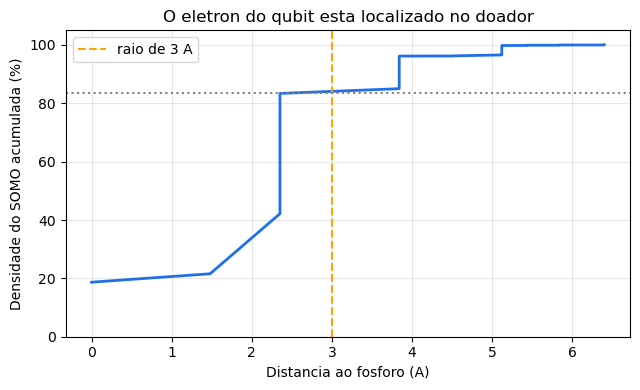

In [13]:
# Visualizando: como a densidade do SOMO decai com a distancia ao fosforo
ordem = np.argsort(dist)
acum = np.cumsum(peso_atomo[ordem]) * 100

plt.figure(figsize=(6.5, 4))
plt.plot(dist[ordem], acum, lw=2, color="#1f6feb")
plt.axvline(3, ls="--", c="orange", label="raio de 3 A")
plt.axhline(acum[dist[ordem] < 3][-1], ls=":", c="gray")
plt.xlabel("Distancia ao fosforo (A)")
plt.ylabel("Densidade do SOMO acumulada (%)")
plt.title("O eletron do qubit esta localizado no doador")
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 105)
plt.tight_layout(); plt.show()

**O resultado que valida toda a Parte I.** O orbital do *qubit* **não** está espalhado pelo nanocristal: a maior parte de sua densidade concentra-se num raio de 3 Å em torno do fósforo.

O elétron excedente do doador está, de fato, **localizado** ao redor do P⁺ — é o "hidrogênio artificial" que a intuição química do Capítulo 3 antecipou, agora confirmado por um cálculo de primeiros princípios. É esse elétron localizado, e o seu spin, que manipularemos como bit quântico.

Por que a localização importa? Um estado deslocalizado seria sensível a **toda** a superfície do nanocristal e às suas imperfeições — péssimo para um *qubit*. A localização é o que protege a informação quântica.

**A seguir.** No Capítulo 5, a Teoria do Funcional da Densidade corrigirá os *gaps* superestimados e nos dará a **densidade de spin** do doador — a porta de entrada para os parâmetros magnéticos do *qubit*.

## Exercícios

Resolva nas células abaixo.

**4.1 O ciclo SCF na prática.** Rode o nanocristal de 0,8 nm com `verbose=4` e conte quantos ciclos o SCF levou. Depois aumente `mf.level_shift` para 0,5 e observe se o número muda.

**4.2 Verificando o escalonamento.** Faça um gráfico log–log do tempo contra `mol.nao` e estime o expoente. Ele se aproxima de 4?

**4.3 Density fitting.** Compare energia total, *gap* e tempo do cálculo de 1,0 nm com e sem `.density_fit()`. Valeu a pena?

**4.4 Sensibilidade à base.** Recalcule o *gap* do nanocristal de 0,8 nm em `sto-3g` e em `6-31g`. O *gap* sobe ou desce? Como isso se relaciona com a caixa de atenção sobre valores absolutos?

**4.5 O papel da passivação.** Construa o nanocristal de 0,8 nm *sem* passivar (H vazio) e tente rodar o SCF. Explique o que acontece, com base nas ligações pendentes do Capítulo 3.

**4.6 Projeto Âncora.** Examine o orbital duplamente ocupado logo **abaixo** do SOMO e o primeiro virtual **acima**. Eles estão localizados no fósforo ou espalhados? O que isso diz sobre a natureza especial do estado do doador?

In [14]:
# 4.1 Ciclos do SCF e efeito do level_shift

In [15]:
# 4.2 Escalonamento log-log

In [16]:
# 4.4 Sensibilidade a base (sto-3g vs 6-31g)

In [17]:
# 4.6 Projeto Ancora: orbitais vizinhos do SOMO